# 🩺 Diabetes Progression Prediction
## Data Science Internship Project

### Dataset: `load_diabetes()` from Scikit-learn

This project predicts the quantitative disease progression score using patient health measurements.

The analysis begins with the required exploratory work and then builds regression models from simple to more advanced:

1. Simple Linear Regression
2. Multiple Linear Regression
3. Decision Tree Regression
4. Random Forest Regression
5. KNN Regression

Model performance is evaluated using **R², MAE and RMSE**.


# 1. Project Introduction

Diabetes progression prediction is treated as a regression problem in which the objective is to estimate a continuous disease progression score from patient health measurements.

The project uses the built-in `load_diabetes()` dataset available in Scikit-learn.



# 2. Problem Statement

The objective is to analyze patient health measurements and develop regression models capable of predicting the disease progression score after one year.

The project first establishes a simple linear baseline, then evaluates whether using multiple features and nonlinear/machine-learning regression methods can improve prediction performance.



# 3. Objectives

- Load and understand the Scikit-learn diabetes dataset.
- Perform exploratory data analysis.
- Study feature correlations.
- Identify influential features.
- Build a Simple Linear Regression model.
- Build a Multiple Linear Regression model.
- Build Decision Tree, Random Forest and KNN regression models.
- Evaluate all models using R², MAE and RMSE.
- Compare model performance.
- Select the best-performing model.
- Analyze actual vs predicted values and residual errors.


# 4. Import Libraries

In [5]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")


Libraries imported successfully.


# 5. Load Dataset

In [6]:

diabetes = load_diabetes(as_frame=True)

df = diabetes.frame.copy()

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# 6. Dataset Overview

In [7]:

print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Number of rows   : 442
Number of columns: 11

Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Data types:


,Data Type
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64


# 7. Feature Description

The diabetes dataset contains 10 features that are used to predict the target value. These features contain different health-related measurements.

* `age` – age measurement
* `sex` – sex-related measurement
* `bmi` – Body Mass Index measurement
* `bp` – blood pressure measurement
* `s1` to `s6` – different blood serum measurements
* `target` – disease progression score after one year

Here, the 10 features are given as input to the machine learning model, and the `target` is the value that the model tries to predict.

The values in the dataset are standardized, so they are not represented in their original units.


# 8. Data Quality Check

In [15]:

print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Total missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
display(df.nunique().to_frame("Unique Values"))


Missing values:


,Missing Values
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


Total missing values: 0

Duplicate rows: 0

Unique values:


,Unique Values
age,58
sex,2
bmi,163
bp,100
s1,141
s2,302
s3,63
s4,66
s5,184
s6,56


# 9. Descriptive Statistics

In [16]:

display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


# 10. Exploratory Data Analysis

## 10.1 Target Distribution

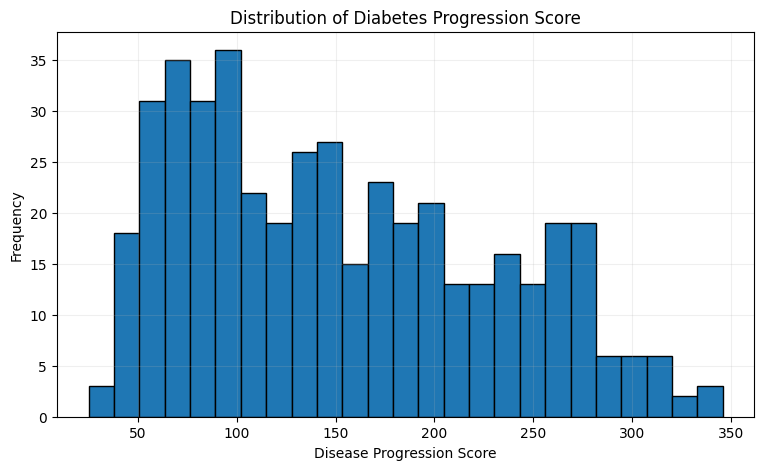

In [17]:

plt.figure(figsize=(9, 5))
plt.hist(df["target"], bins=25, edgecolor="black")
plt.title("Distribution of Diabetes Progression Score")
plt.xlabel("Disease Progression Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


## 10.2 Feature Distributions

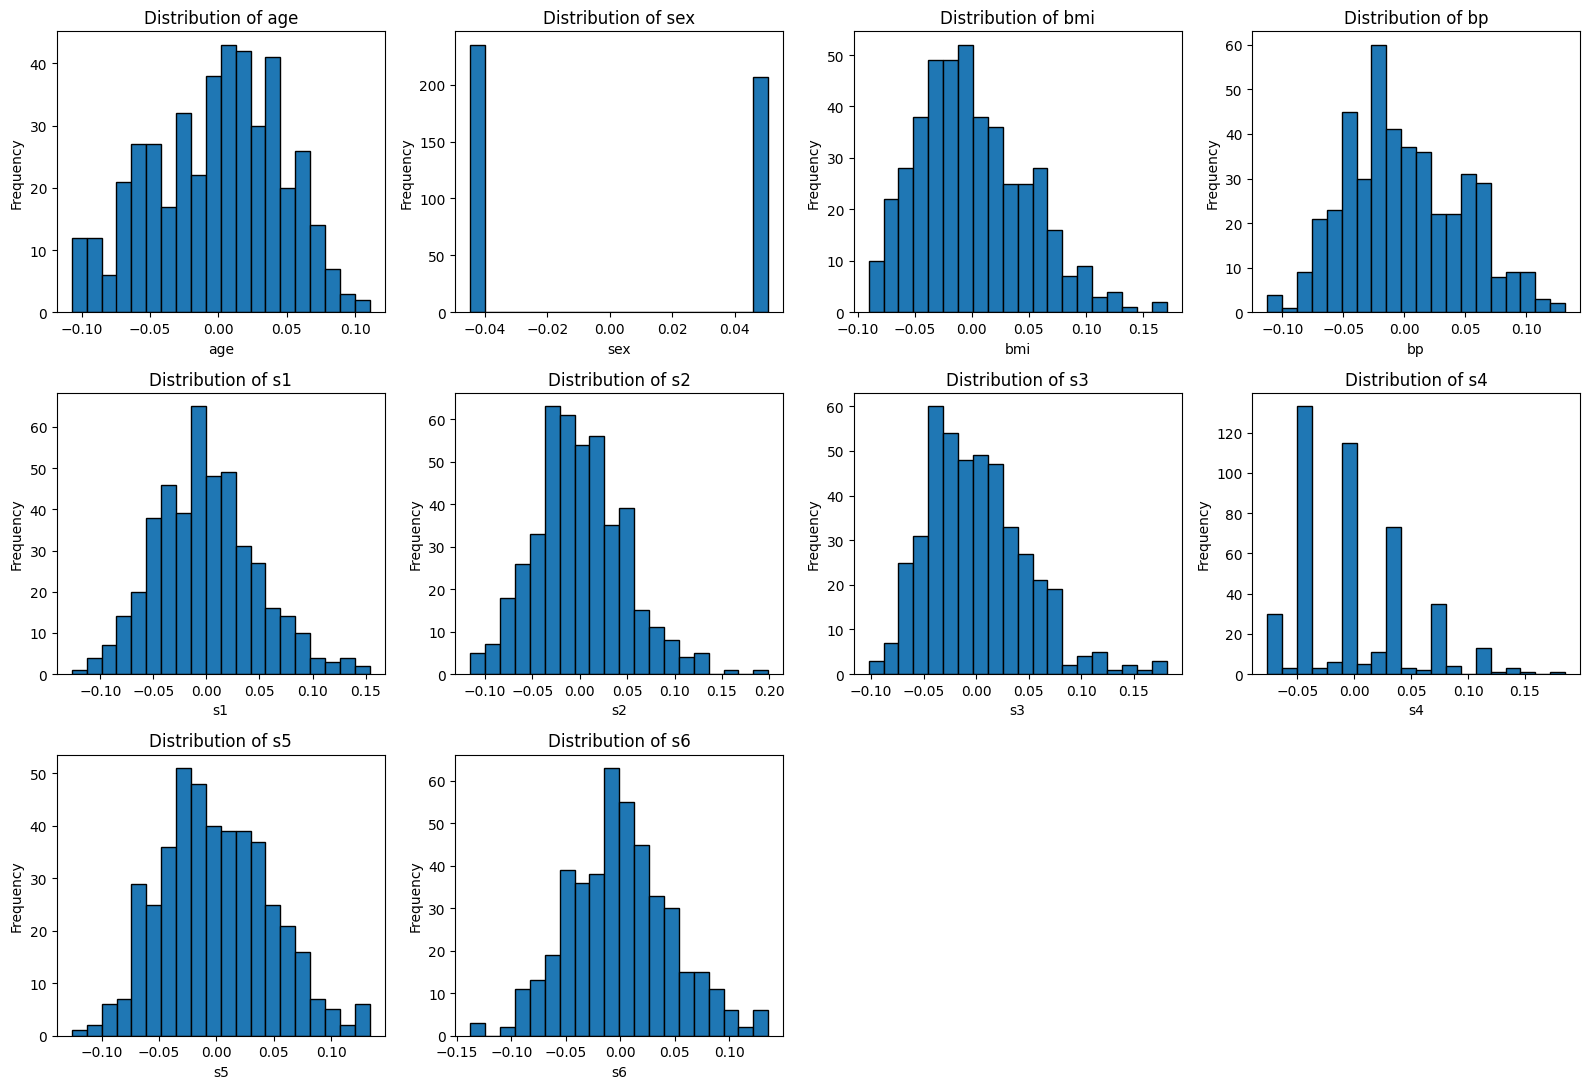

In [18]:

features = [column for column in df.columns if column != "target"]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=20, edgecolor="black")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

for i in range(len(features), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 10.3 Boxplots

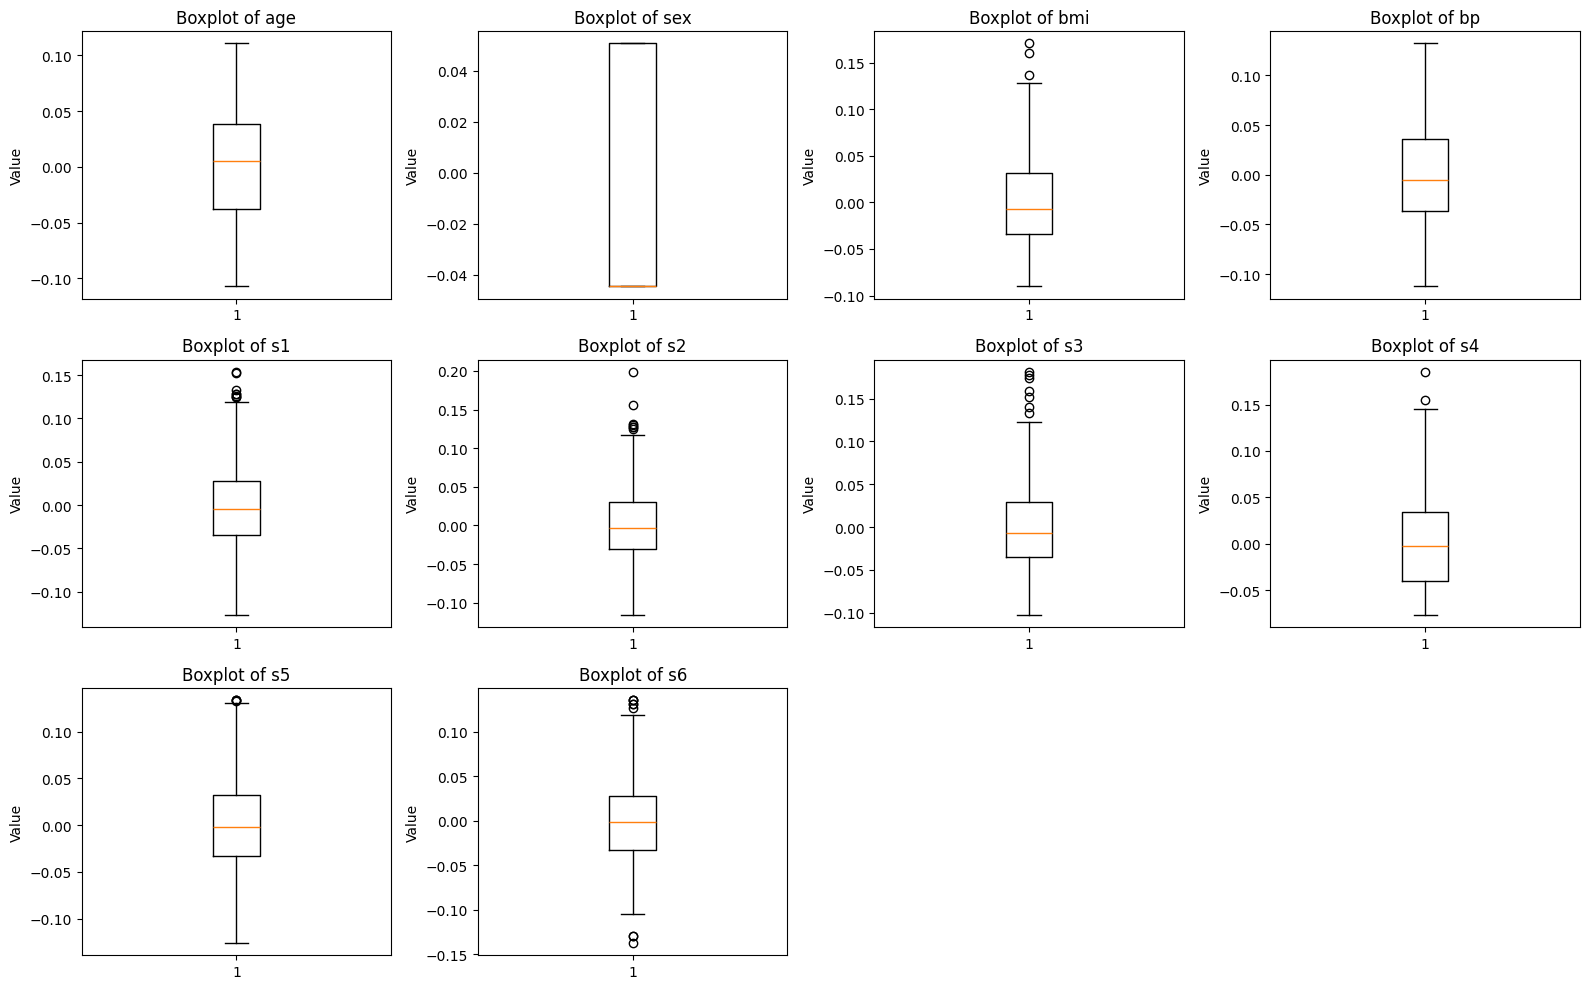

In [19]:

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].boxplot(df[feature])
    axes[i].set_title(f"Boxplot of {feature}")
    axes[i].set_ylabel("Value")

for i in range(len(features), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 10.4 Feature vs Target

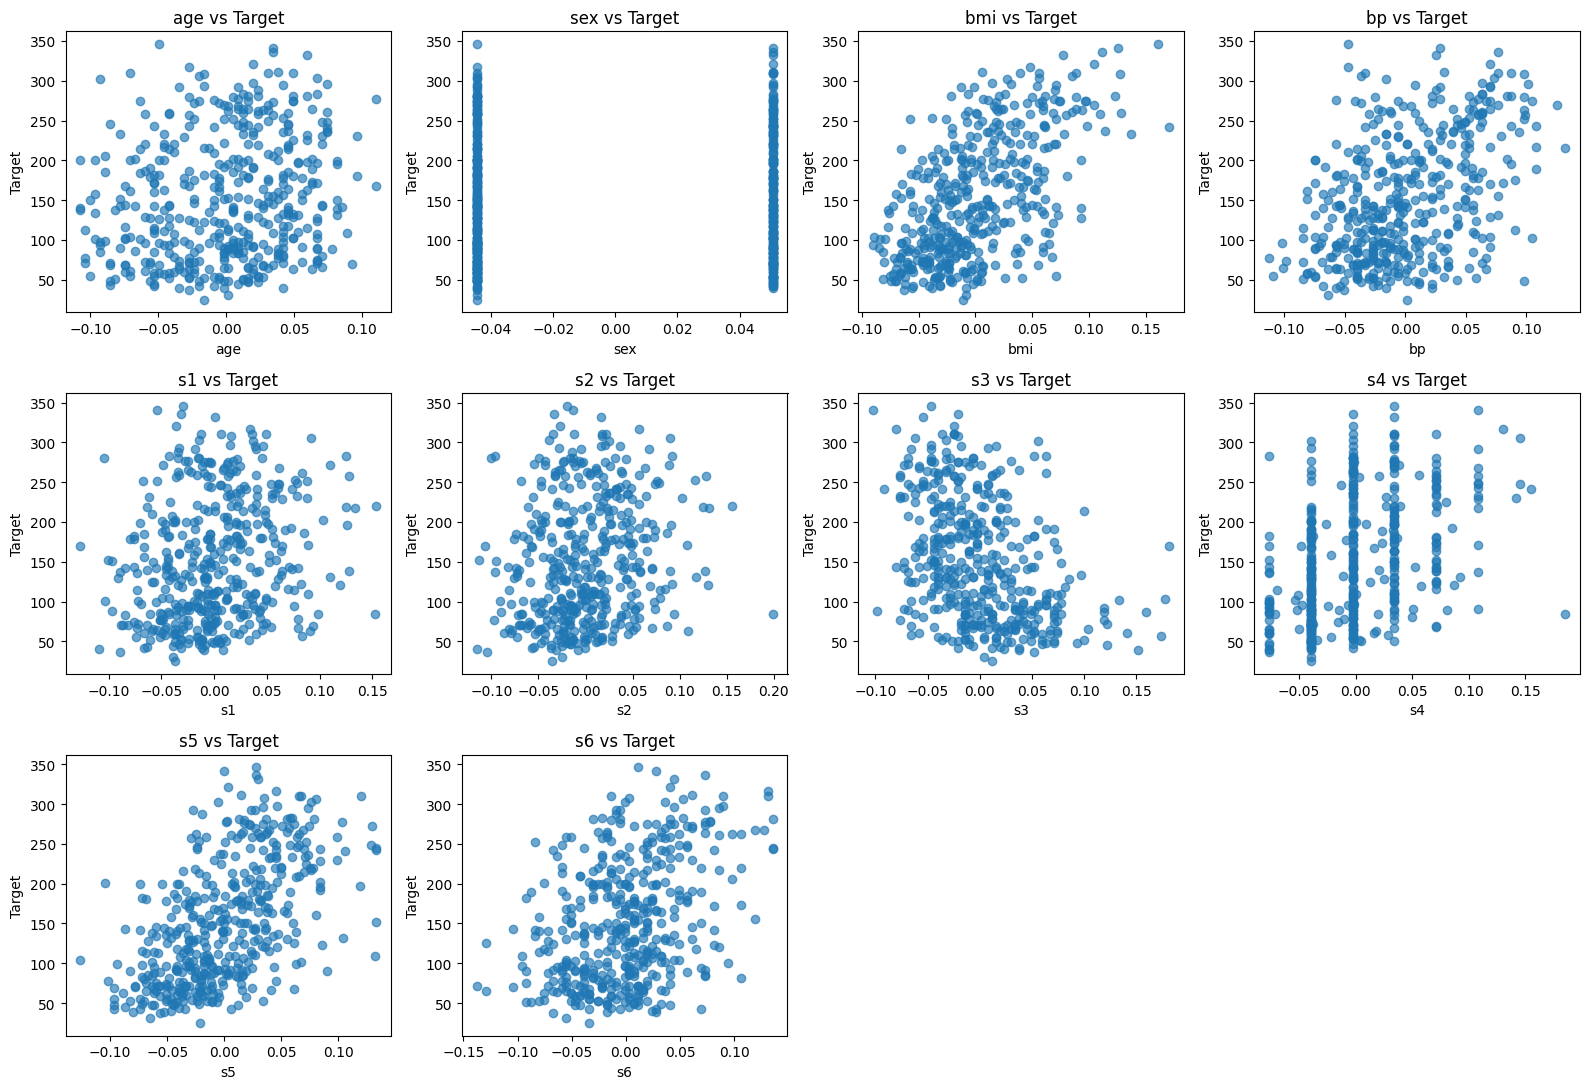

In [20]:

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df["target"], alpha=0.65)
    axes[i].set_title(f"{feature} vs Target")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Target")

for i in range(len(features), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# 11. Correlation Analysis

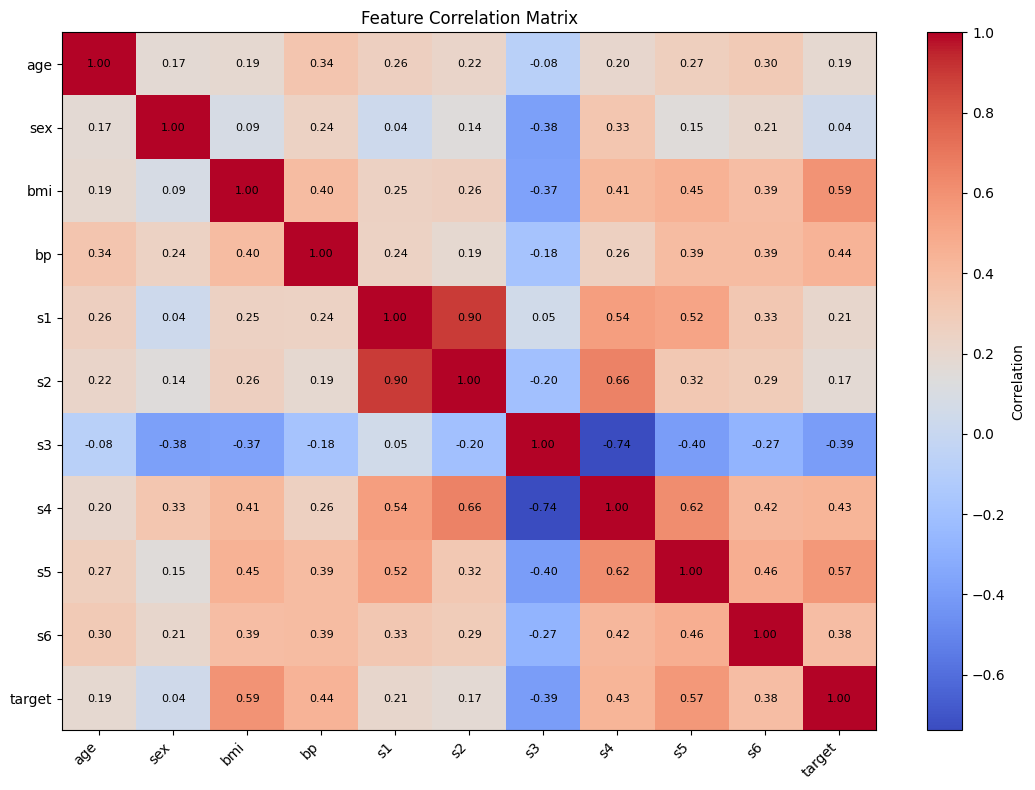

,Correlation with Target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [21]:

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.to_frame("Correlation with Target"))


# 12. Important Feature Analysis

,Feature,Correlation,Absolute Correlation
0,bmi,0.586450,0.586450
1,s5,0.565883,0.565883
2,bp,0.441482,0.441482
3,s4,0.430453,0.430453
4,s3,-0.394789,0.394789
5,s6,0.382483,0.382483
6,s1,0.212022,0.212022
7,age,0.187889,0.187889
8,s2,0.174054,0.174054
9,sex,0.043062,0.043062


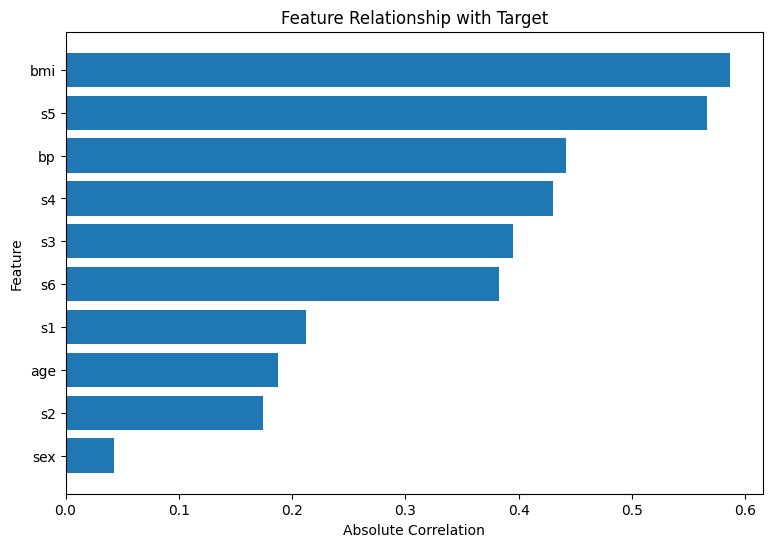

Feature selected for Simple Linear Regression: bmi


In [22]:

important_features = pd.DataFrame({
    "Feature": target_correlations.index,
    "Correlation": target_correlations.values,
    "Absolute Correlation": target_correlations.abs().values
}).sort_values("Absolute Correlation", ascending=False).reset_index(drop=True)

display(important_features)

plt.figure(figsize=(9, 6))
plt.barh(
    important_features["Feature"],
    important_features["Absolute Correlation"]
)
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.title("Feature Relationship with Target")
plt.gca().invert_yaxis()
plt.show()

# Select the strongest feature for Simple Linear Regression.
simple_feature = important_features.iloc[0]["Feature"]
print("Feature selected for Simple Linear Regression:", simple_feature)


# 13. Data Preparation

In [23]:

X = df.drop(columns=["target"])
y = df["target"]

print("Input features:", X.columns.tolist())
print("Target:", "target")


Input features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: target


# 14. Train-Test Split

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 353
Testing samples : 89



# 15. Simple Linear Regression

Simple Linear Regression uses **one independent feature** to predict the target.

The feature selected here is the feature with the strongest absolute correlation with the target, identified in the Important Feature Analysis section.


## 15.1 Training

In [25]:

simple_model = LinearRegression()


simple_model.fit(
    X_train[[simple_feature]],
    y_train
)

print("Simple Linear Regression trained using:", simple_feature)


Simple Linear Regression trained using: bmi


## 15.2 Prediction

In [26]:

simple_predictions = simple_model.predict(
    X_test[[simple_feature]]
)

simple_prediction_table = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": simple_predictions
})

display(simple_prediction_table.head(10))


,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


## 15.3 R², MAE, RMSE

In [27]:

simple_r2 = r2_score(y_test, simple_predictions)
simple_mae = mean_absolute_error(y_test, simple_predictions)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_predictions))

print(f"R²   : {simple_r2:.4f}")
print(f"MAE  : {simple_mae:.4f}")
print(f"RMSE : {simple_rmse:.4f}")


R²   : 0.2334
MAE  : 52.2600
RMSE : 63.7325


## 15.4 Coefficient Analysis

Intercept: 152.00335421448167
Coefficient: 998.5776891375593


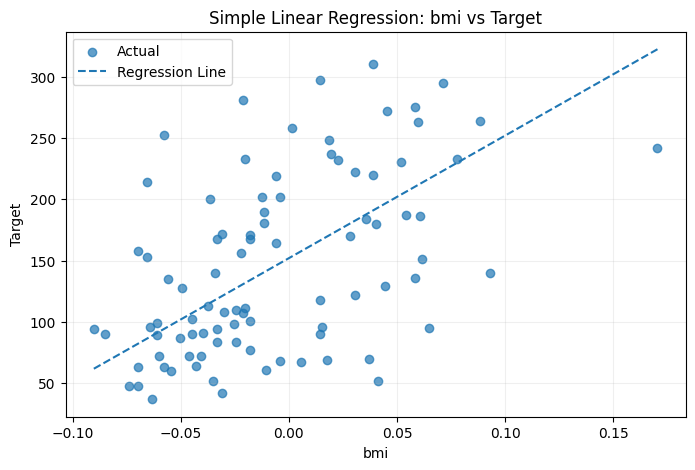

In [28]:

print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_[0])

plt.figure(figsize=(8, 5))
plt.scatter(
    X_test[simple_feature],
    y_test,
    alpha=0.7,
    label="Actual"
)

sorted_x = np.sort(X_test[simple_feature].values)
sorted_pred = simple_model.predict(
    sorted_x.reshape(-1, 1)
)

plt.plot(
    sorted_x,
    sorted_pred,
    linestyle="--",
    label="Regression Line"
)

plt.xlabel(simple_feature)
plt.ylabel("Target")
plt.title(f"Simple Linear Regression: {simple_feature} vs Target")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 16. Multiple Linear Regression

Multiple Linear Regression uses **all available input features together** to predict the target.

This provides a stronger baseline than Simple Linear Regression because the model can use information from all 10 features.


## 16.1 Training

In [29]:

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

print("Multiple Linear Regression trained successfully.")


Multiple Linear Regression trained successfully.


## 16.2 Prediction

In [30]:

multiple_predictions = multiple_model.predict(X_test)

display(pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": multiple_predictions
}).head(10))


,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


## 16.3 R², MAE, RMSE

In [31]:

multiple_r2 = r2_score(y_test, multiple_predictions)
multiple_mae = mean_absolute_error(y_test, multiple_predictions)
multiple_rmse = np.sqrt(mean_squared_error(y_test, multiple_predictions))

print(f"R²   : {multiple_r2:.4f}")
print(f"MAE  : {multiple_mae:.4f}")
print(f"RMSE : {multiple_rmse:.4f}")


R²   : 0.4526
MAE  : 42.7941
RMSE : 53.8534


## 16.4 Coefficient Analysis

,Feature,Coefficient,Absolute Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


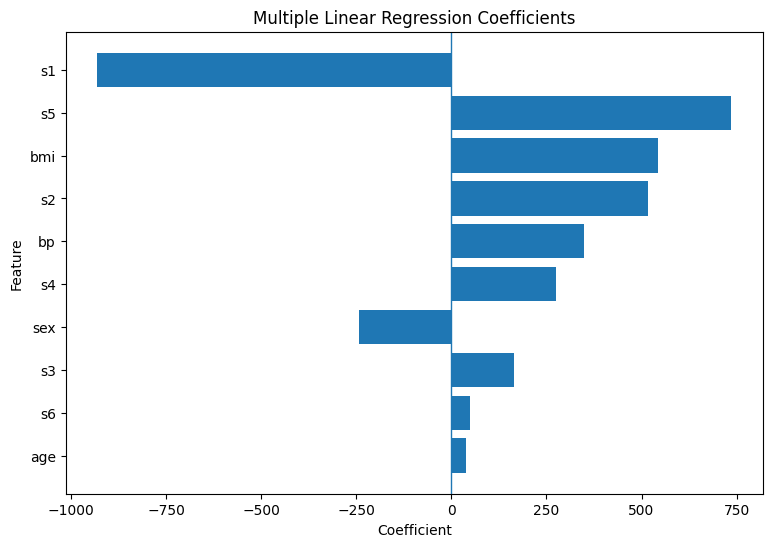

In [32]:

multiple_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
})

multiple_coefficients["Absolute Coefficient"] = (
    multiple_coefficients["Coefficient"].abs()
)

multiple_coefficients = multiple_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(multiple_coefficients)

plt.figure(figsize=(9, 6))
plt.barh(
    multiple_coefficients["Feature"],
    multiple_coefficients["Coefficient"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Multiple Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()



# 17. Decision Tree Regression

Decision Tree Regression learns nonlinear relationships by dividing the feature space into decision-based regions.


## 17.1 Training

In [33]:

decision_tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=4
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regression trained successfully.")


Decision Tree Regression trained successfully.


## 17.2 Prediction

In [34]:

decision_tree_predictions = decision_tree_model.predict(X_test)

display(pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": decision_tree_predictions
}).head(10))


,Actual,Predicted
0,219.0,175.333333
1,70.0,182.773333
2,202.0,175.333333
3,230.0,241.200000
4,111.0,121.859375
5,84.0,90.333333
6,242.0,203.500000
7,272.0,241.200000
8,94.0,134.809524
9,96.0,182.773333


## 17.3 Evaluation

In [35]:

decision_tree_r2 = r2_score(y_test, decision_tree_predictions)
decision_tree_mae = mean_absolute_error(y_test, decision_tree_predictions)
decision_tree_rmse = np.sqrt(mean_squared_error(y_test, decision_tree_predictions))

print(f"R²   : {decision_tree_r2:.4f}")
print(f"MAE  : {decision_tree_mae:.4f}")
print(f"RMSE : {decision_tree_rmse:.4f}")


R²   : 0.3264
MAE  : 47.0454
RMSE : 59.7408



# 18. Random Forest Regression

Random Forest Regression combines multiple decision trees to produce a more stable prediction than a single decision tree.


## 18.1 Training

In [36]:

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Regression trained successfully.")


Random Forest Regression trained successfully.


## 18.2 Prediction

In [37]:

random_forest_predictions = random_forest_model.predict(X_test)

display(pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": random_forest_predictions
}).head(10))


,Actual,Predicted
0,219.0,141.516667
1,70.0,178.506667
2,202.0,154.166667
3,230.0,253.423333
4,111.0,109.006667
5,84.0,124.846667
6,242.0,244.016667
7,272.0,212.723333
8,94.0,149.353333
9,96.0,179.713333


## 18.3 Evaluation

In [38]:

random_forest_r2 = r2_score(y_test, random_forest_predictions)
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))

print(f"R²   : {random_forest_r2:.4f}")
print(f"MAE  : {random_forest_mae:.4f}")
print(f"RMSE : {random_forest_rmse:.4f}")


R²   : 0.4341
MAE  : 44.5784
RMSE : 54.7571



# 19. KNN Regression

K-Nearest Neighbors Regression predicts a new observation using the target values of nearby training observations.

Because KNN is distance-based, the features are standardized before training.


## 19.1 Training

In [39]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN Regression trained successfully.")


KNN Regression trained successfully.


## 19.2 Prediction

In [40]:

knn_predictions = knn_model.predict(X_test_scaled)

display(pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": knn_predictions
}).head(10))


,Actual,Predicted
0,219.0,125.6
1,70.0,160.2
2,202.0,153.0
3,230.0,238.0
4,111.0,153.4
5,84.0,150.4
6,242.0,246.2
7,272.0,170.0
8,94.0,94.4
9,96.0,104.6


## 19.3 Evaluation

In [41]:

knn_r2 = r2_score(y_test, knn_predictions)
knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))

print(f"R²   : {knn_r2:.4f}")
print(f"MAE  : {knn_mae:.4f}")
print(f"RMSE : {knn_rmse:.4f}")


R²   : 0.4248
MAE  : 42.7775
RMSE : 55.2037



# 20. Model Performance Comparison

All five regression models are compared using the same test set.

### Models
- Simple Linear Regression
- Multiple Linear Regression
- Decision Tree Regression
- Random Forest Regression
- KNN Regression

### Metrics
- **R²:** Higher is better
- **MAE:** Lower is better
- **RMSE:** Lower is better


In [42]:

results_df = pd.DataFrame([
    {
        "Model": "Simple Linear Regression",
        "R²": simple_r2,
        "MAE": simple_mae,
        "RMSE": simple_rmse
    },
    {
        "Model": "Multiple Linear Regression",
        "R²": multiple_r2,
        "MAE": multiple_mae,
        "RMSE": multiple_rmse
    },
    {
        "Model": "Decision Tree Regression",
        "R²": decision_tree_r2,
        "MAE": decision_tree_mae,
        "RMSE": decision_tree_rmse
    },
    {
        "Model": "Random Forest Regression",
        "R²": random_forest_r2,
        "MAE": random_forest_mae,
        "RMSE": random_forest_rmse
    },
    {
        "Model": "KNN Regression",
        "R²": knn_r2,
        "MAE": knn_mae,
        "RMSE": knn_rmse
    }
])

display(results_df.round(4))


,Model,R²,MAE,RMSE
0,Simple Linear Regression,0.2334,52.2600,63.7325
1,Multiple Linear Regression,0.4526,42.7941,53.8534
2,Decision Tree Regression,0.3264,47.0454,59.7408
3,Random Forest Regression,0.4341,44.5784,54.7571
4,KNN Regression,0.4248,42.7775,55.2037


### 20.1 R² Comparison

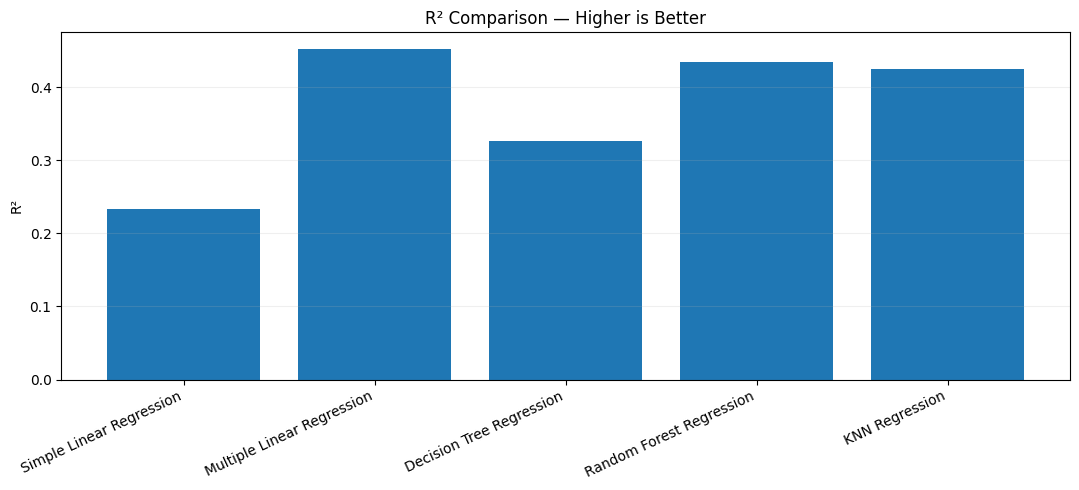

In [43]:

plt.figure(figsize=(11, 5))
plt.bar(results_df["Model"], results_df["R²"])
plt.title("R² Comparison — Higher is Better")
plt.ylabel("R²")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### 20.2 MAE Comparison

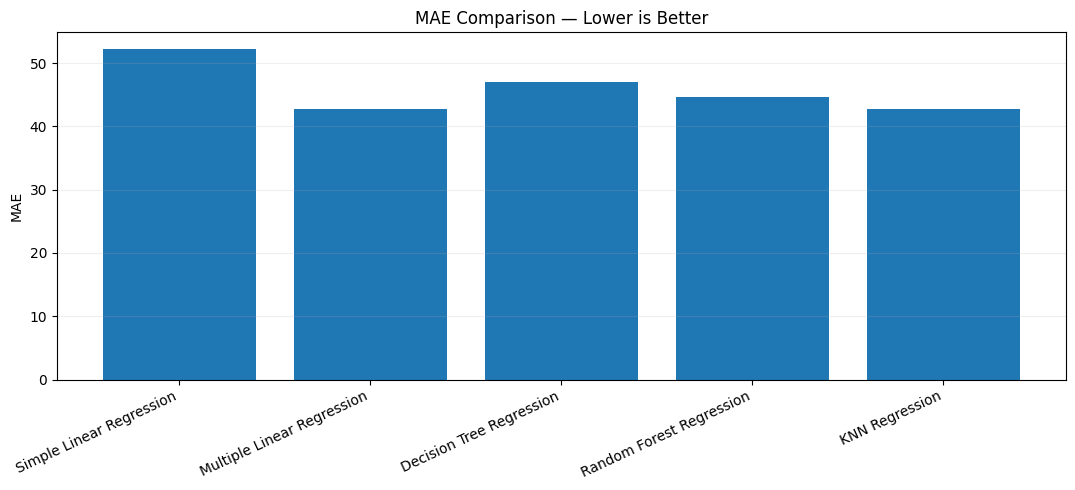

In [44]:

plt.figure(figsize=(11, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison — Lower is Better")
plt.ylabel("MAE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### 20.3 RMSE Comparison

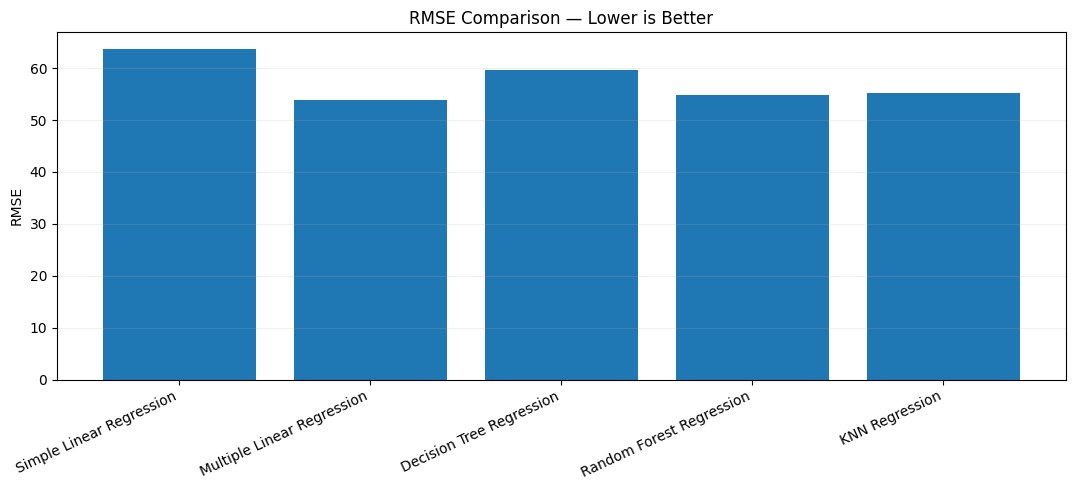

In [45]:

plt.figure(figsize=(11, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison — Lower is Better")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()



# 21. Best Model Selection

For regression, there is no single "accuracy" percentage.

The best model should generally have:
- Higher **R²**
- Lower **MAE**
- Lower **RMSE**

A combined ranking is used below to make the selection transparent.


In [46]:

ranking = results_df.copy()

ranking["R² Rank"] = ranking["R²"].rank(
    ascending=False,
    method="min"
)

ranking["MAE Rank"] = ranking["MAE"].rank(
    ascending=True,
    method="min"
)

ranking["RMSE Rank"] = ranking["RMSE"].rank(
    ascending=True,
    method="min"
)

ranking["Combined Rank"] = (
    ranking["R² Rank"] +
    ranking["MAE Rank"] +
    ranking["RMSE Rank"]
)

ranking = ranking.sort_values(
    ["Combined Rank", "R²"],
    ascending=[True, False]
).reset_index(drop=True)

display(ranking.round(4))

best_model_name = ranking.iloc[0]["Model"]
print("Best overall model:", best_model_name)


,Model,R²,MAE,RMSE,R² Rank,MAE Rank,RMSE Rank,Combined Rank
0,Multiple Linear Regression,0.4526,42.7941,53.8534,1.0,2.0,1.0,4.0
1,Random Forest Regression,0.4341,44.5784,54.7571,2.0,3.0,2.0,7.0
2,KNN Regression,0.4248,42.7775,55.2037,3.0,1.0,3.0,7.0
3,Decision Tree Regression,0.3264,47.0454,59.7408,4.0,4.0,4.0,12.0
4,Simple Linear Regression,0.2334,52.2600,63.7325,5.0,5.0,5.0,15.0


Best overall model: Multiple Linear Regression



# 22. Actual vs Predicted

The actual-vs-predicted plot shows how closely the model predictions follow the real target values.

Points closer to the diagonal reference line indicate better prediction agreement.


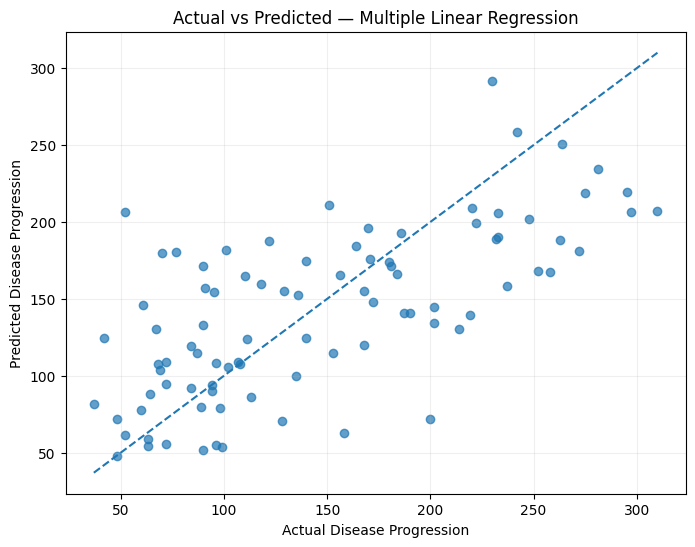

In [47]:

prediction_map = {
    "Simple Linear Regression": simple_predictions,
    "Multiple Linear Regression": multiple_predictions,
    "Decision Tree Regression": decision_tree_predictions,
    "Random Forest Regression": random_forest_predictions,
    "KNN Regression": knn_predictions
}

best_predictions = prediction_map[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.grid(alpha=0.2)
plt.show()



# 24. Feature Importance

For tree-based models, feature importance is obtained directly from the trained model.

For Multiple Linear Regression, the absolute coefficient magnitude provides an interpretable measure of feature influence.

The section below reports feature importance for the best model.


Importance method: Absolute Linear Regression coefficients


,Feature,Importance
4,s1,931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


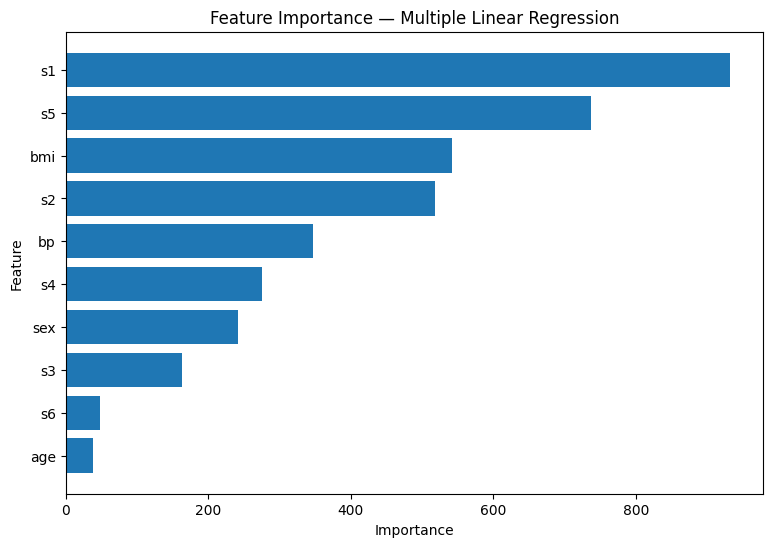

In [49]:

if best_model_name == "Decision Tree Regression":
    importance_values = decision_tree_model.feature_importances_
    importance_method = "Decision Tree feature importance"

elif best_model_name == "Random Forest Regression":
    importance_values = random_forest_model.feature_importances_
    importance_method = "Random Forest feature importance"

elif best_model_name == "Multiple Linear Regression":
    importance_values = np.abs(multiple_model.coef_)
    importance_method = "Absolute Linear Regression coefficients"

elif best_model_name == "Simple Linear Regression":
    importance_values = np.zeros(len(X.columns))
    importance_values[list(X.columns).index(simple_feature)] = abs(
        simple_model.coef_[0]
    )
    importance_method = "Simple Linear Regression coefficient"

else:
    
    importance_values = important_features.set_index("Feature").reindex(X.columns)["Absolute Correlation"].values
    importance_method = "Absolute feature-target correlation (KNN has no native feature importance)"

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
)

print("Importance method:", importance_method)
display(feature_importance_df)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance — {best_model_name}")
plt.gca().invert_yaxis()
plt.show()



# 25. Key Findings

After running the notebook, summarize the actual results using the generated tables and graphs.

### Points to report

- The dataset contains 442 observations and 10 input features.
- Data quality was checked for missing values and duplicates.
- Exploratory analysis was performed for the target and all input features.
- Feature correlations were analyzed to identify relationships with the target.
- Simple Linear Regression provided a one-feature baseline.
- Multiple Linear Regression used all available features.
- Decision Tree, Random Forest and KNN provided additional regression approaches.
- R², MAE and RMSE were used for model evaluation.
- The best-performing model was selected using the combined metric ranking.
- Actual-vs-predicted and residual analysis were used to inspect prediction behavior.

**Important:** Feature correlation or model importance does not prove medical causation.



# 26. Limitations

- The dataset is relatively small for a real-world healthcare application.
- The Scikit-learn dataset contains standardized feature values.
- Results depend on the selected train-test split.
- Model performance on this dataset does not guarantee performance on external data.
- Correlation and feature importance represent predictive relationships, not causation.
- This project should not be used as a clinical diagnostic system.



# 27. Future Scope

Possible future improvements include:

- Hyperparameter tuning for Decision Tree, Random Forest and KNN.
- K-fold cross-validation.
- Testing the models on an independent dataset.
- More detailed error analysis.
- Explainable AI methods such as SHAP.
- Deployment as a simple web application.
- Monitoring model performance on new data.


# 28. Final Conclusion

* Successfully analyzed the Scikit-learn diabetes dataset and predicted disease progression using regression techniques.
* Performed EDA and correlation analysis to understand the dataset and identify important features.
* Implemented Simple Linear Regression, Multiple Linear Regression, Decision Tree, Random Forest, and KNN Regression.
* Evaluated all models using R², MAE, and RMSE for performance comparison.
* **Multiple Linear Regression achieved the best overall performance** among the tested models.
* Gained practical experience in data analysis, regression modeling, feature analysis, and machine learning evaluation.
